# 02 — Bald Eagle: open canonical (g09) and secondary (g02) geometries

**Stage 1 Task 1.** Resolve the open items from STATUS.md by opening the Bald Eagle Dam Break example, confirming CRS handling, and selecting the canonical pilot geometry for Phase A.0 Stage 2 onward.

The example ships with **12 alternate geometry definitions** of the same hydraulic system (`.g01.hdf` through `.g13.hdf`, skipping `.g04`/`.g05`/`.g07`). They all cover the same flow area; they differ in mesh resolution and in which expert-placed breaklines were included.

**Canonical pick — `g09`:**
- 4 semantically named breaklines including `SayersDam` (the headline feature of the *dam-break* study) and channel segments `Lower` / `Middle` / `Upper`.
- The only one of the 12 with a **CRS embedded directly in the HDF** — exercises the prefer-HDF-CRS code path the feature pipeline will need.

**Secondary pick — `g02`:**
- 7 breaklines total: the same channel segments (`Lower`, `Middle`), plus `HighwayRoad` (road embankment), plus four generic `Breakline 1-4` flow-alignment helpers. More labels but noisier — useful as additional pilot signal at Stage 2.

Per ADR 003 (amended 2026-05-23), both contribute to the *prior*; neither is "ground truth." The canonical/secondary split is about training-signal quality, not which is "correct."

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show as rio_show
from rashdf import RasGeomHdf

## 2. Paths

In [2]:
REPO_ROOT = Path.cwd().parent  # notebook lives in notebooks/, repo is one level up
PILOT_DIR = (
    REPO_ROOT
    / "data" / "raw" / "usace" / "RAS Samples" / "Example_Projects_7_0"
    / "2D Unsteady Flow Hydraulics" / "BaldEagleCrkMulti2D"
)
assert PILOT_DIR.exists(), PILOT_DIR

GEOM_CANONICAL = PILOT_DIR / "BaldEagleDamBrk.g09.hdf"
GEOM_SECONDARY = PILOT_DIR / "BaldEagleDamBrk.g02.hdf"

TERRAIN_DIR = PILOT_DIR / "Terrain"
TERRAIN_DEM = TERRAIN_DIR / "Terrain50.baldeagledem.tif"
TERRAIN_PRJ = TERRAIN_DIR / "Projection.prj"

for p in [GEOM_CANONICAL, GEOM_SECONDARY, TERRAIN_DEM, TERRAIN_PRJ]:
    assert p.exists(), p
print("All paths resolved.")

All paths resolved.


## 3. Inventory of all 12 BaldEagle geometries

Quick scan: how many cells, perimeters, breaklines, refinement regions does each carry, and does any of them embed a CRS in the HDF itself? Sets the basis for the canonical pick.

In [3]:
rows = []
for g in sorted(PILOT_DIR.glob("BaldEagleDamBrk.g*.hdf")):
    h = RasGeomHdf(g)
    try:
        n_areas = len(h.mesh_areas())
        n_cells = len(h.mesh_cell_polygons())
        n_bls = len(h.breaklines())
        rrs = h.refinement_regions()
        n_rrs = len(rrs) if hasattr(rrs, "__len__") else 0
        crs = h.projection()
        crs_str = "embedded" if crs is not None else "-"
        rows.append((g.name, n_areas, n_cells, n_bls, n_rrs, crs_str))
    finally:
        h.close()

header = f"{'file':<32} {'areas':>6} {'cells':>8} {'bls':>6} {'rrs':>6}  CRS"
print(header)
print("-" * len(header))
for r in rows:
    print(f"{r[0]:<32} {r[1]:>6} {r[2]:>8} {r[3]:>6} {r[4]:>6}  {r[5]}")

file                              areas    cells    bls    rrs  CRS
-------------------------------------------------------------------
BaldEagleDamBrk.g01.hdf               1    87039      1      0  -
BaldEagleDamBrk.g02.hdf               1    28449      7      0  -
BaldEagleDamBrk.g03.hdf               1    24718      3      0  -
BaldEagleDamBrk.g06.hdf               3     4120      0      0  -
BaldEagleDamBrk.g08.hdf               1    14206      3      0  -
BaldEagleDamBrk.g09.hdf               1    18066      4      0  embedded
BaldEagleDamBrk.g10.hdf               1     5330      0      0  -
BaldEagleDamBrk.g11.hdf               2     4425      3      0  -
BaldEagleDamBrk.g12.hdf               1     3439      0      0  -
BaldEagleDamBrk.g13.hdf               1    14364      4      0  -


**Observations.**

- All 12 geometries describe the same study area (~22.5 mi × 15.4 mi over `BaldEagleCr`).
- **No refinement regions** anywhere — confirms we will need the FEMA bulk corpus before Stage 5 (resolution prediction). Phase A doesn't need them.
- Only **`g09`** embeds a CRS in the HDF. This is good evidence we need a 'prefer-HDF, fall-back-terrain' CRS resolver in the feature pipeline.

## 4. Terrain — load DEM and confirm CRS via the projection sidecar

In [4]:
print(f"Projection.prj contents:\n{TERRAIN_PRJ.read_text()[:300]}...")
print()

with rasterio.open(TERRAIN_DEM) as src:
    print(f"DEM:        {TERRAIN_DEM.name}")
    print(f"CRS:        {src.crs}")
    print(f"Shape:      {src.height} x {src.width}  ({src.height * src.width / 1e6:.2f} Mpx)")
    print(f"Resolution: {src.res}")
    print(f"Bounds:     {tuple(round(b, 1) for b in src.bounds)}")
    terrain_crs = src.crs
    terrain_bounds = src.bounds
    terrain_arr = src.read(1, masked=True)
    terrain_transform = src.transform

Projection.prj contents:
PROJCS["NAD_1983_StatePlane_Pennsylvania_North_FIPS_3701_Feet",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic"],PARAMETER["False_Easting",19685...

DEM:        Terrain50.baldeagledem.tif
CRS:        EPSG:2271
Shape:      6902 x 8643  (59.65 Mpx)
Resolution: (36.504512049933, 36.504512049933)
Bounds:     (1834327.2, 162918.8, 2149835.7, 414872.9)


## 5. Canonical geometry — `g09`

In [5]:
g = RasGeomHdf(GEOM_CANONICAL)

perim_g09 = g.mesh_areas()
cells_g09 = g.mesh_cell_polygons()
bls_g09 = g.breaklines()
hdf_crs_g09 = g.projection()

print(f"HDF-embedded CRS: {hdf_crs_g09.name} (EPSG:{hdf_crs_g09.to_epsg()})")
print()
area_names = list(perim_g09['mesh_name'])
print(f"Perimeters: {len(perim_g09)}  | area name(s): {area_names}")
print(f"Cells:      {len(cells_g09):,}")
print(f"Breaklines: {len(bls_g09)}")
print()
print("Breakline details:")
print(f"  {'name':<14} {'length (ft)':>13} {'vertices':>10}")
for _, row in bls_g09.iterrows():
    geom = row.geometry
    pts = len(list(geom.coords)) if geom.geom_type == "LineString" else sum(len(list(p.coords)) for p in geom.geoms)
    name = row['name']
    print(f"  {name:<14} {geom.length:>13,.1f} {pts:>10}")

g.close()

HDF-embedded CRS: NAD83 / Pennsylvania North (ftUS) (EPSG:2271)

Perimeters: 1  | area name(s): ['BaldEagleCr']
Cells:      18,066
Breaklines: 4

Breakline details:
  name             length (ft)   vertices
  SayersDam            7,618.7         41
  Lower               15,780.0         89
  Middle              10,299.8        122
  Upper                8,700.8         99


## 6. Secondary geometry — `g02`

In [6]:
g = RasGeomHdf(GEOM_SECONDARY)

perim_g02 = g.mesh_areas()
cells_g02 = g.mesh_cell_polygons()
bls_g02 = g.breaklines()
hdf_crs_g02 = g.projection()

print(f"HDF-embedded CRS: {hdf_crs_g02}")
print()
area_names = list(perim_g02['mesh_name'])
print(f"Perimeters: {len(perim_g02)}  | area name(s): {area_names}")
print(f"Cells:      {len(cells_g02):,}")
print(f"Breaklines: {len(bls_g02)}")
print()
print("Breakline details:")
print(f"  {'name':<14} {'length (ft)':>13} {'vertices':>10}")
for _, row in bls_g02.iterrows():
    geom = row.geometry
    pts = len(list(geom.coords)) if geom.geom_type == "LineString" else sum(len(list(p.coords)) for p in geom.geoms)
    name = row['name']
    print(f"  {name:<14} {geom.length:>13,.1f} {pts:>10}")

g.close()

HDF-embedded CRS: None

Perimeters: 1  | area name(s): ['BaldEagleCr']
Cells:      28,449
Breaklines: 7

Breakline details:
  name             length (ft)   vertices
  Lower               15,780.0         89
  Middle              10,299.8        122
  Breakline 1          9,546.7         18
  Breakline 2          3,823.4         10
  Breakline 3          1,215.6          9
  Breakline 4          6,232.1         12
  HighwayRoad          4,830.2         17


## 7. CRS resolution — prefer HDF, fall back to terrain

A small helper sketching the pattern the features module will use: try the HDF first (works for g09), then fall back to the terrain raster (necessary for Muncie and for g02 / most other Bald Eagle geometries).

In [7]:
def resolve_project_crs(geom_hdf_path: Path, terrain_path: Path):
    """Return (source, pyproj.CRS), preferring the HDF if it carries one."""
    h = RasGeomHdf(geom_hdf_path)
    try:
        hdf_crs = h.projection()
    finally:
        h.close()
    if hdf_crs is not None:
        return ("hdf", hdf_crs)
    with rasterio.open(terrain_path) as src:
        return ("terrain", src.crs)

for label, path in [('g09', GEOM_CANONICAL), ('g02', GEOM_SECONDARY)]:
    source, crs = resolve_project_crs(path, TERRAIN_DEM)
    crs_repr = crs.to_string() if hasattr(crs, 'to_string') else str(crs)
    print(f"{label}: source={source:<8} {crs_repr}")

g09: source=hdf      EPSG:2271
g02: source=terrain  EPSG:2271


## 8. Spatial sanity check

Mesh extent must sit inside the terrain extent for both geometries. Same flow area, so same expected bounds.

In [8]:
for label, perim in [("g09", perim_g09), ("g02", perim_g02)]:
    minx, miny, maxx, maxy = perim.total_bounds
    inside = (
        minx >= terrain_bounds.left
        and miny >= terrain_bounds.bottom
        and maxx <= terrain_bounds.right
        and maxy <= terrain_bounds.top
    )
    print(f"{label}: perimeter bounds = ({minx:,.0f}, {miny:,.0f}) -> ({maxx:,.0f}, {maxy:,.0f})  inside terrain: {inside}")

print(f"\nterrain bounds: ({terrain_bounds.left:,.0f}, {terrain_bounds.bottom:,.0f}) -> ({terrain_bounds.right:,.0f}, {terrain_bounds.top:,.0f})")

g09: perimeter bounds = (1,965,982, 289,578) -> (2,084,790, 371,008)  inside terrain: True
g02: perimeter bounds = (1,965,982, 289,578) -> (2,084,790, 371,008)  inside terrain: True

terrain bounds: (1,834,327, 162,919) -> (2,149,836, 414,873)


## 9. Overlay — `g09` (canonical)

Terrain hillshade + perimeter + cells + breaklines. We want to see the 4 named breaklines sit where they should: `SayersDam` across the dam, `Lower`/`Middle`/`Upper` tracking the channel.

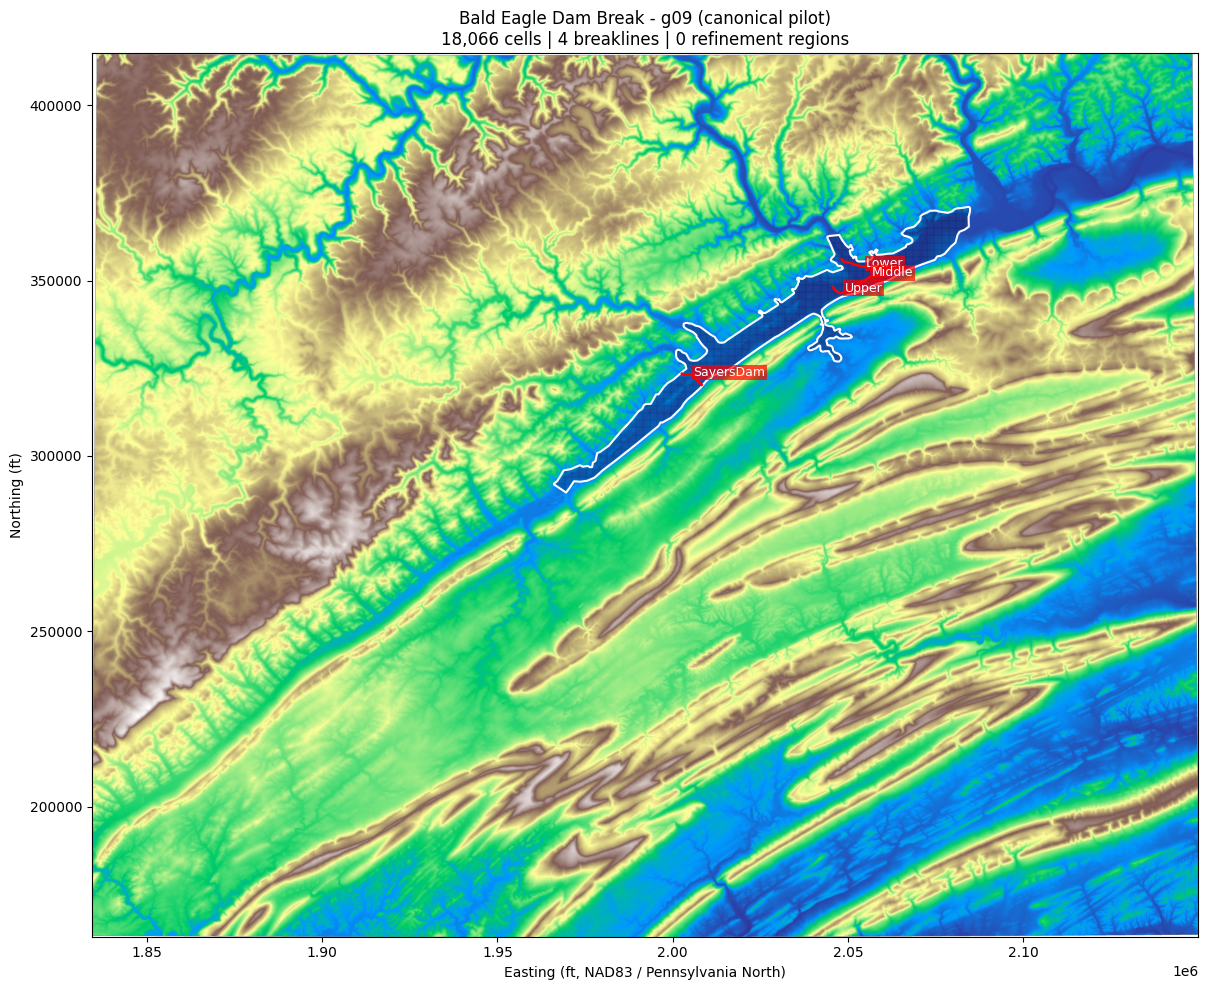

In [9]:
def with_crs(gdf, crs):
    if gdf.crs is None:
        return gdf.set_crs(crs, allow_override=False)
    return gdf

perim_g09 = with_crs(perim_g09, terrain_crs)
cells_g09 = with_crs(cells_g09, terrain_crs)
bls_g09 = with_crs(bls_g09, terrain_crs)

fig, ax = plt.subplots(figsize=(14, 10))
rio_show(terrain_arr, transform=terrain_transform, ax=ax, cmap="terrain")
cells_g09.boundary.plot(ax=ax, color="black", linewidth=0.05, alpha=0.6)
perim_g09.boundary.plot(ax=ax, color="white", linewidth=1.5)
bls_g09.plot(ax=ax, color="red", linewidth=1.8)

for _, row in bls_g09.iterrows():
    mid = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(row["name"], (mid.x, mid.y), color="white", fontsize=9,
                bbox=dict(facecolor="red", alpha=0.7, pad=1, edgecolor="none"))

ax.set_title("Bald Eagle Dam Break - g09 (canonical pilot)\n"
             f"{len(cells_g09):,} cells | {len(bls_g09)} breaklines | 0 refinement regions")
ax.set_xlabel("Easting (ft, NAD83 / Pennsylvania North)")
ax.set_ylabel("Northing (ft)")
plt.tight_layout()
plt.show()

## 10. Overlay — `g02` (secondary)

7 breaklines on a different mesh of the same area. Compare against g09: same channel features (`Lower`, `Middle`), missing `Upper` and `SayersDam`, plus 4 generic helpers + `HighwayRoad`.

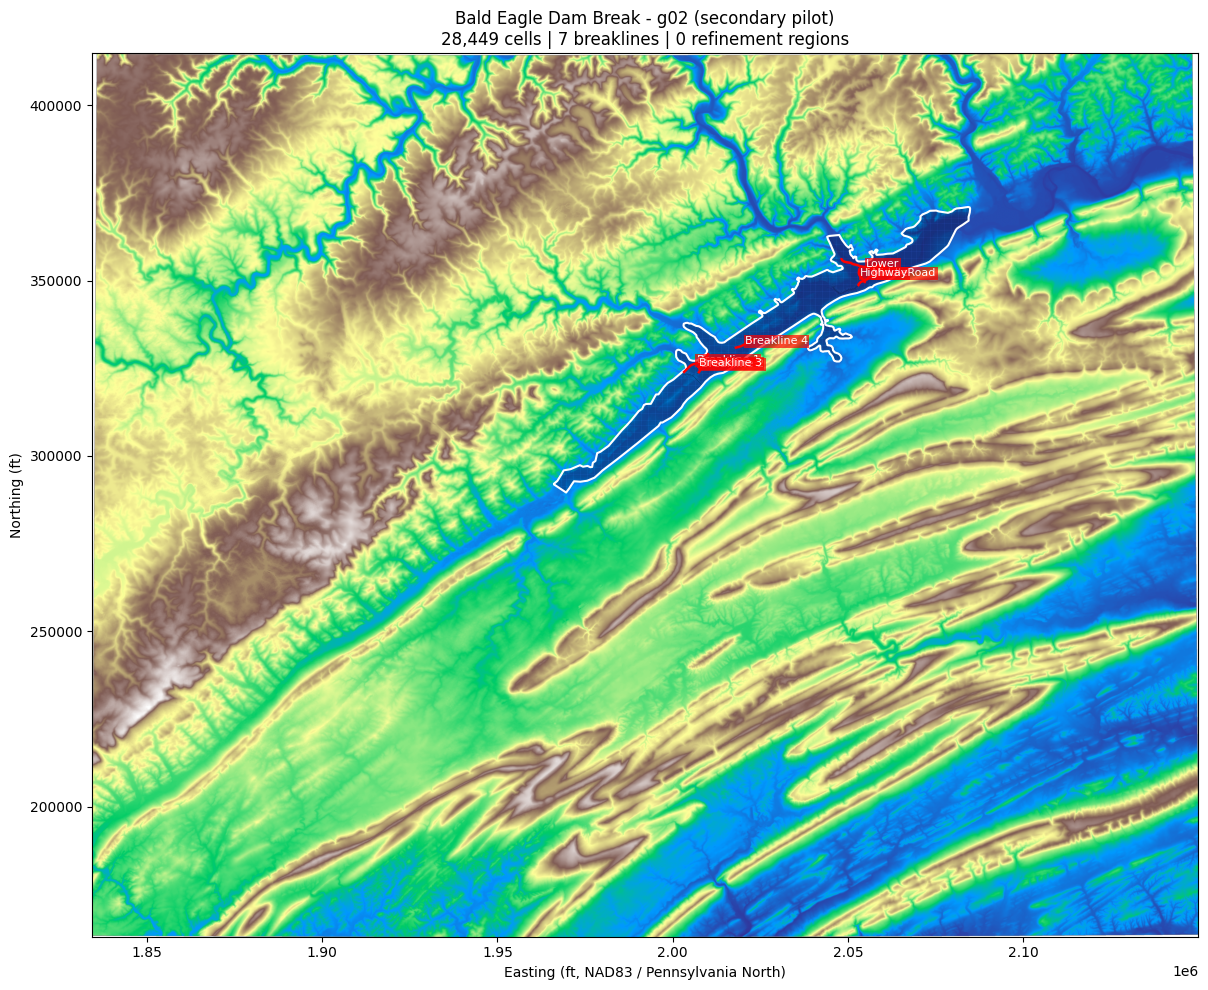

In [10]:
perim_g02 = with_crs(perim_g02, terrain_crs)
cells_g02 = with_crs(cells_g02, terrain_crs)
bls_g02 = with_crs(bls_g02, terrain_crs)

fig, ax = plt.subplots(figsize=(14, 10))
rio_show(terrain_arr, transform=terrain_transform, ax=ax, cmap="terrain")
cells_g02.boundary.plot(ax=ax, color="black", linewidth=0.05, alpha=0.6)
perim_g02.boundary.plot(ax=ax, color="white", linewidth=1.5)
bls_g02.plot(ax=ax, color="red", linewidth=1.8)

for _, row in bls_g02.iterrows():
    mid = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(row["name"], (mid.x, mid.y), color="white", fontsize=8,
                bbox=dict(facecolor="red", alpha=0.7, pad=1, edgecolor="none"))

ax.set_title("Bald Eagle Dam Break - g02 (secondary pilot)\n"
             f"{len(cells_g02):,} cells | {len(bls_g02)} breaklines | 0 refinement regions")
ax.set_xlabel("Easting (ft, NAD83 / Pennsylvania North)")
ax.set_ylabel("Northing (ft)")
plt.tight_layout()
plt.show()

## 11. Findings & decisions

**Open items from STATUS.md, closed:**

1. **Bald Eagle Dam Break opens cleanly with rashdf.** All 12 geometries load without error; mesh + perimeter + breaklines extract as GeoDataFrames identical in shape to Muncie. The empty-`refinement_regions()` issue reported under rashdf earlier no longer surfaces under 0.12.0 — `len() == 0` returns cleanly.
2. **CRS embedding is variable across HEC-RAS HDFs.** `g09` carries full WKT (NAD_1983_StatePlane_Pennsylvania_North_FIPS_3701_Feet, US ft); the other 11 do not. Muncie's `g04` also did not. The feature pipeline must implement **prefer-HDF-CRS, fall-back-terrain** as a first-class behavior, not an edge case.

**Canonical pilot pick:** `BaldEagleDamBrk.g09.hdf` — clean semantic labels (`SayersDam`, `Lower`, `Middle`, `Upper`), embedded CRS for code-path coverage, 18,066 cells. `g02` retained as secondary for additional pilot signal.

**Notes for downstream stages:**

- **Stage 1 Task 4 (breakline rasterizer):** breakline polylines here have 18-122 vertices and lengths in the 1-16 kft range. Buffer width is a hyperparameter — exposed, not hard-coded.
- **Stage 5 (resolution model):** Bald Eagle has 0 refinement regions across all 12 geometries. The pilots will not produce refinement-region labels; that's Stage 3 / bulk-corpus work.
- **Per ADR 003 (amended):** g09's 4 named + g02's 7 mixed breaklines are *prior signal*, not ground truth. The Stage 2 model is expected to overfit on these and is not required to "match" them exactly.
